# Failure Analysis — YOLOX-m@960 baseline on val set

Cel: znaleźć 3-5 głównych failure modes żeby kierunkowo ulepszać model.

**Workflow:**
1. Load predictions + GT
2. Compute per-image F1
3. Look at 50 worst images, categorize errors
4. Aggregate + find patterns
5. Write up findings

In [1]:
import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from collections import defaultdict

## Load data

In [2]:
with open('val_predictions.pkl', 'rb') as f:
    predictions = pickle.load(f)

with open('val_annotations.json') as f:
    ann_data = json.load(f)

img_info = {img['id']: img for img in ann_data['images']}
gt_per_image = defaultdict(list)
for a in ann_data['annotations']:
    gt_per_image[a['image_id']].append(a)

print(f'Images: {len(img_info)}')
print(f'Predictions: {sum(len(d) for d in predictions.values())} dets across {len(predictions)} images')
print(f'GT annotations: {sum(len(g) for g in gt_per_image.values())} across {len(gt_per_image)} images')

Images: 6777
Predictions: 125414 dets across 6777 images
GT annotations: 109351 across 6777 images


In [9]:
# Load per-image scores (precomputed)
scores = pd.read_csv('per_image_scores.csv')
scores = scores.sort_values('f1')
print(f'Worst 10 images by F1:')
print(scores.head(10))

Worst 10 images by F1:
      image_id   file_name  tp  fp  fn  precision  recall      f1  n_gt  \
5132      5132  005132.jpg   1   5   2     0.1667  0.3333  0.2222     3   
5295      5295  005295.jpg   1   4   2     0.2000  0.3333  0.2500     3   
2960      2960  002960.jpg   1   4   2     0.2000  0.3333  0.2500     3   
1468      1468  001468.jpg   1   4   1     0.2000  0.5000  0.2857     2   
4698      4698  004698.jpg   1   2   3     0.3333  0.2500  0.2857     4   
4362      4362  004362.jpg   2   6   3     0.2500  0.4000  0.3077     5   
6442      6442  006442.jpg   1   1   3     0.5000  0.2500  0.3333     4   
5155      5155  005155.jpg   1   3   1     0.2500  0.5000  0.3333     2   
1384      1384  001384.jpg   1   3   1     0.2500  0.5000  0.3333     2   
6384      6384  006384.jpg   1   3   1     0.2500  0.5000  0.3333     2   

      n_pred  
5132       6  
5295       5  
2960       5  
1468       5  
4698       3  
4362       8  
6442       2  
5155       4  
1384       4  
6

## Helper: match predictions to GT

GT keypoints są w 4K, predictions w FullHD → skaluj predictions ×2 (lub GT ×0.5).

In [10]:
def match_pred_to_gt(preds, gts, distance_threshold_4k=50):
    """Match predictions to GT by pelvis_ground keypoint (index 1) distance.
    
    Returns: matches (pred_idx, gt_idx, distance), unmatched_preds, unmatched_gts
    All in 4K coords.
    """
    # pred pelvis_ground in 4K coords
    pred_points_4k = []
    for p in preds:
        kpts = p['keypoints_fullhd']
        pg = kpts[1]  # pelvis_ground
        pred_points_4k.append([pg[0] * 2, pg[1] * 2])
    pred_points_4k = np.array(pred_points_4k) if pred_points_4k else np.empty((0, 2))
    
    # GT pelvis_ground (already in 4K from val.json)
    gt_points_4k = []
    for g in gts:
        kpts = g['keypoints']
        if isinstance(kpts[0], list):
            pg = kpts[1]
            gt_points_4k.append([pg[0], pg[1]])
        else:
            gt_points_4k.append([kpts[3], kpts[4]])  # flat format: pelvis_ground at index [3:5]
    gt_points_4k = np.array(gt_points_4k) if gt_points_4k else np.empty((0, 2))
    
    matches = []
    used_gt = set()
    
    if len(pred_points_4k) == 0 or len(gt_points_4k) == 0:
        return [], list(range(len(preds))), list(range(len(gts)))
    
    # Greedy matching by distance (pred sorted by score descending)
    pred_order = sorted(range(len(preds)), key=lambda i: -preds[i]['score'])
    matched_pred = set()
    for pi in pred_order:
        dists = np.linalg.norm(gt_points_4k - pred_points_4k[pi], axis=1)
        dists[[g for g in used_gt]] = 1e9
        if len(dists) == 0:
            continue
        gi = int(np.argmin(dists))
        if dists[gi] < distance_threshold_4k:
            matches.append((pi, gi, float(dists[gi])))
            used_gt.add(gi)
            matched_pred.add(pi)
    
    unmatched_preds = [i for i in range(len(preds)) if i not in matched_pred]
    unmatched_gts = [i for i in range(len(gts)) if i not in used_gt]
    return matches, unmatched_preds, unmatched_gts

# Test on first worst image
worst_img_id = int(scores.iloc[0]['image_id'])
preds = predictions.get(worst_img_id, [])
gts = gt_per_image.get(worst_img_id, [])
matches, unmatched_p, unmatched_g = match_pred_to_gt(preds, gts)
print(f'Image {worst_img_id}: {len(preds)} preds, {len(gts)} GT')
print(f'  {len(matches)} matched, {len(unmatched_p)} FP, {len(unmatched_g)} FN')

Image 5132: 6 preds, 3 GT
  1 matched, 5 FP, 2 FN


## Visualize one worst image

Zielone = GT, czerwone = predicted. Side-by-side: obraz + pitch top-down.

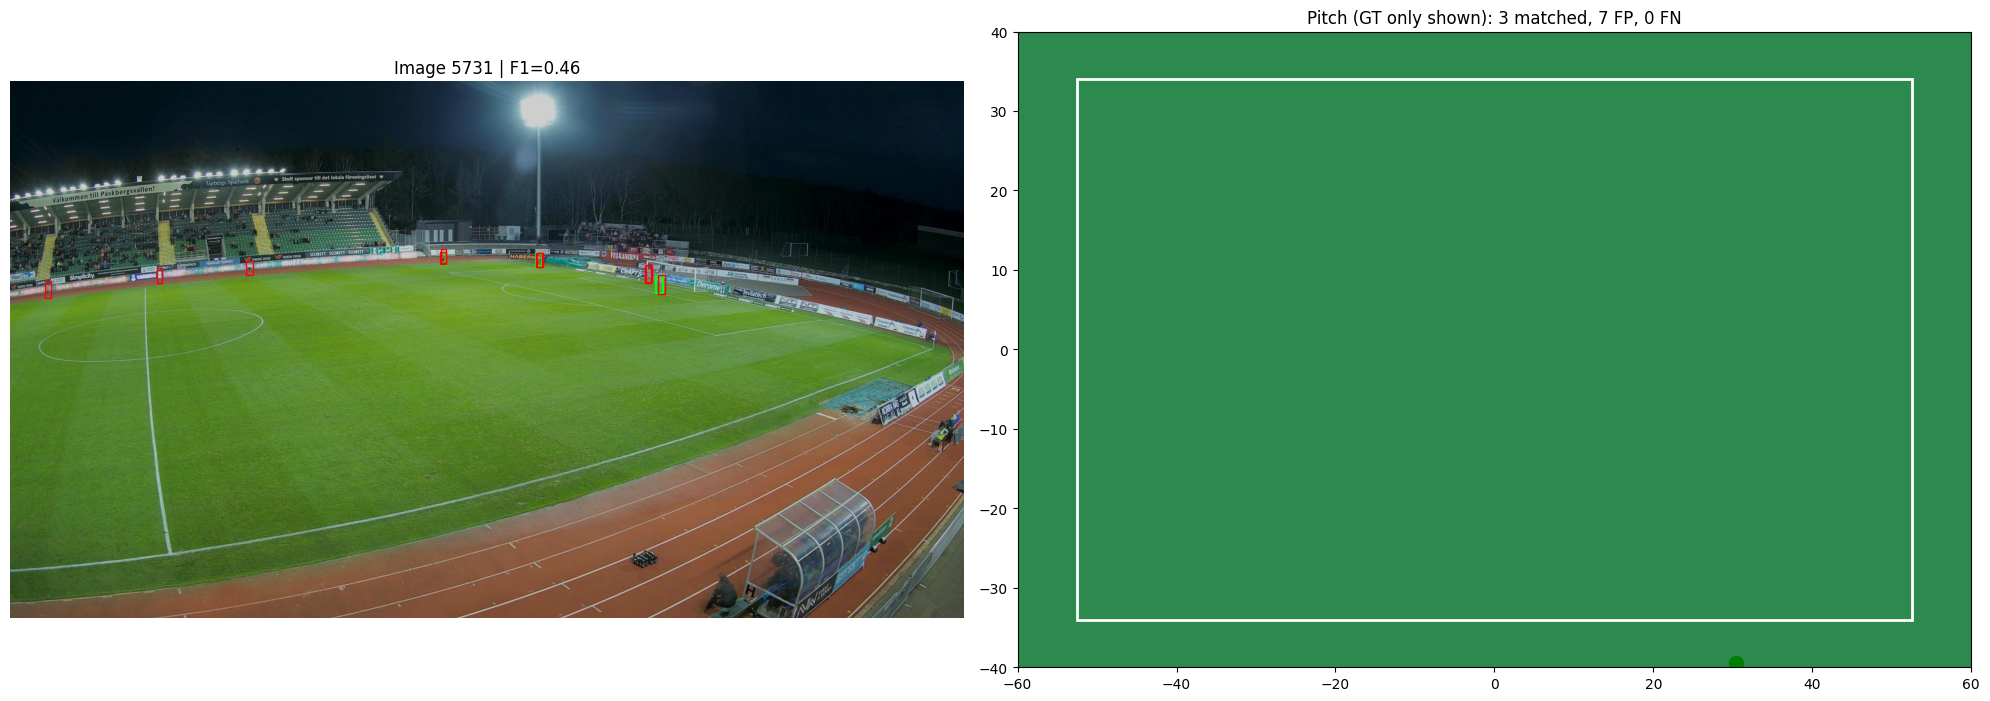

In [14]:
def visualize_image(img_id, save_path=None):
    info = img_info[img_id]
    preds = predictions.get(img_id, [])
    gts = gt_per_image.get(img_id, [])
    matches, unmatched_p, unmatched_g = match_pred_to_gt(preds, gts)
    
    # Load image
    img_path = Path('top50_worst_images') / info['file_name'].split('/')[-1]
    if not img_path.exists():
        print(f'Image not found: {img_path}')
        return
    img = Image.open(img_path)
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    axes[0].imshow(img)
    axes[0].set_title(f'Image {img_id} | F1={scores[scores["image_id"]==img_id]["f1"].values[0]:.2f}')
    
    # GT bboxes (green)
    for g in gts:
        bbox = g['bbox']  # 4K, need to scale to FullHD if image is FullHD
        # Detect if image is FullHD by size
        scale = img.width / 3840.0  # if 0.5 → FullHD
        x, y, w, h = [v * scale for v in bbox]
        rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='lime', facecolor='none')
        axes[0].add_patch(rect)
    
    # Predicted bboxes (red)
    for p in preds:
        if p['bbox_fullhd'] is None:
            continue
        x1, y1, x2, y2 = p['bbox_fullhd']
        # Scale to image size
        scale = img.width / 1920.0
        rect = patches.Rectangle((x1*scale, y1*scale), (x2-x1)*scale, (y2-y1)*scale,
                                  linewidth=1.0, edgecolor='red', facecolor='none')
        axes[0].add_patch(rect)
    
    axes[0].axis('off')
    
    # Pitch top-down
    pitch = plt.Rectangle((-52.5, -34), 105, 68, fill=False, edgecolor='white', linewidth=2)
    axes[1].add_patch(pitch)
    axes[1].set_facecolor('#2d8a4e')
    
    # GT positions
    for g in gts:
        if 'position_on_pitch' in g:
            pos = g['position_on_pitch']
            axes[1].plot(pos[0], pos[1], 'go', markersize=10)
    
    # Predicted positions — from keypoints using camera matrix
    # (simplified: plot pelvis_ground kpt x,y in FullHD and skip analytical localization)
    # (for proper pitch plot would need sskit, skipping here)
    
    axes[1].set_xlim(-60, 60)
    axes[1].set_ylim(-40, 40)
    axes[1].set_aspect('equal')
    axes[1].set_title(f'Pitch (GT only shown): {len(matches)} matched, {len(unmatched_p)} FP, {len(unmatched_g)} FN')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

visualize_image(5731)

## Batch visualize top 50 worst and categorize

Dla każdego obrazu zadaj sobie pytania:
1. Ilu zawodników model zgubił? (unmatched_gts)
2. Ile false positives? (unmatched_preds)
3. Gdzie są zgubieni: blisko/daleko kamery? przy linii bocznej? w tłumie?
4. Co to za FP: sędzia? kibice? halucynacja?
5. Czy to ten sam stadion/kamera co inne w top-50?

Zapisuj tag do df.

In [6]:
# Template do wypełnienia ręcznie (albo automatycznie z heurystyk)
# Tagi: missed_small, missed_occluded, missed_edge, false_positive_ref,
#       false_positive_crowd, bad_keypoint, wrong_localization

annotations_df = []

for _, row in scores.head(50).iterrows():
    img_id = int(row['image_id'])
    annotations_df.append({
        'image_id': img_id,
        'f1': row['f1'],
        'tp': row['tp'], 'fp': row['fp'], 'fn': row['fn'],
        'primary_error': '',  # fill manually after looking
        'notes': '',
    })

annotations_df = pd.DataFrame(annotations_df)
print(annotations_df.head())

   image_id      f1  tp  fp  fn primary_error notes
0      5132  0.2222   1   5   2                    
1      5295  0.2500   1   4   2                    
2      2960  0.2500   1   4   2                    
3      1468  0.2857   1   4   1                    
4      4698  0.2857   1   2   3                    


## Heuristic categorization (start here, refine manually)

Proste heurystyki:
- Dużo FN, małe bboxy w GT → `missed_small`
- Dużo FP, duże score → `false_positive_*` (manually separate ref/crowd)
- FN >> FP → model underfits
- FP >> FN → score threshold za niski

In [7]:
# Auto-categorize rough patterns
for i, row in annotations_df.iterrows():
    img_id = row['image_id']
    gts = gt_per_image.get(img_id, [])
    if row['fn'] > row['fp']:
        # Check if GT bboxes are mostly small
        if gts:
            areas = [g['area'] for g in gts]
            small_ratio = sum(1 for a in areas if a < 4096) / len(areas)  # 4K: 64x64
            if small_ratio > 0.5:
                annotations_df.at[i, 'primary_error'] = 'missed_small'
            else:
                annotations_df.at[i, 'primary_error'] = 'missed_large'
    else:
        annotations_df.at[i, 'primary_error'] = 'false_positive'

print(annotations_df['primary_error'].value_counts())

primary_error
false_positive    45
missed_small       5
Name: count, dtype: int64


## Per-camera / per-stadium breakdown

Czy jakaś kamera/stadion konsekwentnie gorsza?

In [8]:
# Image file_names often contain camera/stadium info (e.g. 'stadium_X/camera_Y/frame_N.jpg')
for _, row in scores.head(50).iterrows():
    img_id = int(row['image_id'])
    fn = img_info[img_id]['file_name']
    print(f'f1={row["f1"]:.2f}  {fn}')

# Spróbuj wyodrębnić camera/stadium z ścieżek

f1=0.22  005132.jpg
f1=0.25  005295.jpg
f1=0.25  002960.jpg
f1=0.29  001468.jpg
f1=0.29  004698.jpg
f1=0.31  004362.jpg
f1=0.33  006442.jpg
f1=0.33  005155.jpg
f1=0.33  001384.jpg
f1=0.33  006384.jpg
f1=0.40  002207.jpg
f1=0.40  003146.jpg
f1=0.40  002911.jpg
f1=0.40  002034.jpg
f1=0.40  006470.jpg
f1=0.40  006716.jpg
f1=0.40  000494.jpg
f1=0.43  002762.jpg
f1=0.43  004544.jpg
f1=0.44  004849.jpg
f1=0.44  006236.jpg
f1=0.44  004662.jpg
f1=0.44  002428.jpg
f1=0.44  004850.jpg
f1=0.44  003460.jpg
f1=0.44  003094.jpg
f1=0.44  004108.jpg
f1=0.46  000414.jpg
f1=0.46  005731.jpg
f1=0.46  003842.jpg
f1=0.47  004536.jpg
f1=0.50  001348.jpg
f1=0.50  001761.jpg
f1=0.50  002404.jpg
f1=0.50  002940.jpg
f1=0.50  001554.jpg
f1=0.50  005788.jpg
f1=0.50  002245.jpg
f1=0.50  006583.jpg
f1=0.50  005858.jpg
f1=0.50  000031.jpg
f1=0.50  006754.jpg
f1=0.50  006634.jpg
f1=0.50  002970.jpg
f1=0.50  004768.jpg
f1=0.50  004489.jpg
f1=0.50  004473.jpg
f1=0.50  000477.jpg
f1=0.50  003664.jpg
f1=0.50  002644.jpg


## Final summary

Po przejrzeniu top-50 wypełnij:

| Kategoria | Count | % |
|-----------|-------|---|
| missed_small | ? | ? |
| missed_occluded | ? | ? |
| false_positive_ref | ? | ? |
| false_positive_crowd | ? | ? |
| wrong_localization | ? | ? |

I napisz `failure_analysis_m960.md` z:
- Top 3 failure modes
- Per-camera findings (jeśli są)
- Rekomendacja

In [ ]:
Obrazy


In [11]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
from pathlib import Path

# Załaduj dane (tak jak w notebooku)
with open('val_predictions.pkl', 'rb') as f:
    predictions = pickle.load(f)

with open('val_annotations.json') as f:
    ann_data = json.load(f)

img_info = {img['id']: img for img in ann_data['images']}
gt_per_image = defaultdict(list)
for a in ann_data['annotations']:
    gt_per_image[a['image_id']].append(a)

scores = pd.read_csv('per_image_scores.csv')
scores = scores.sort_values('f1')


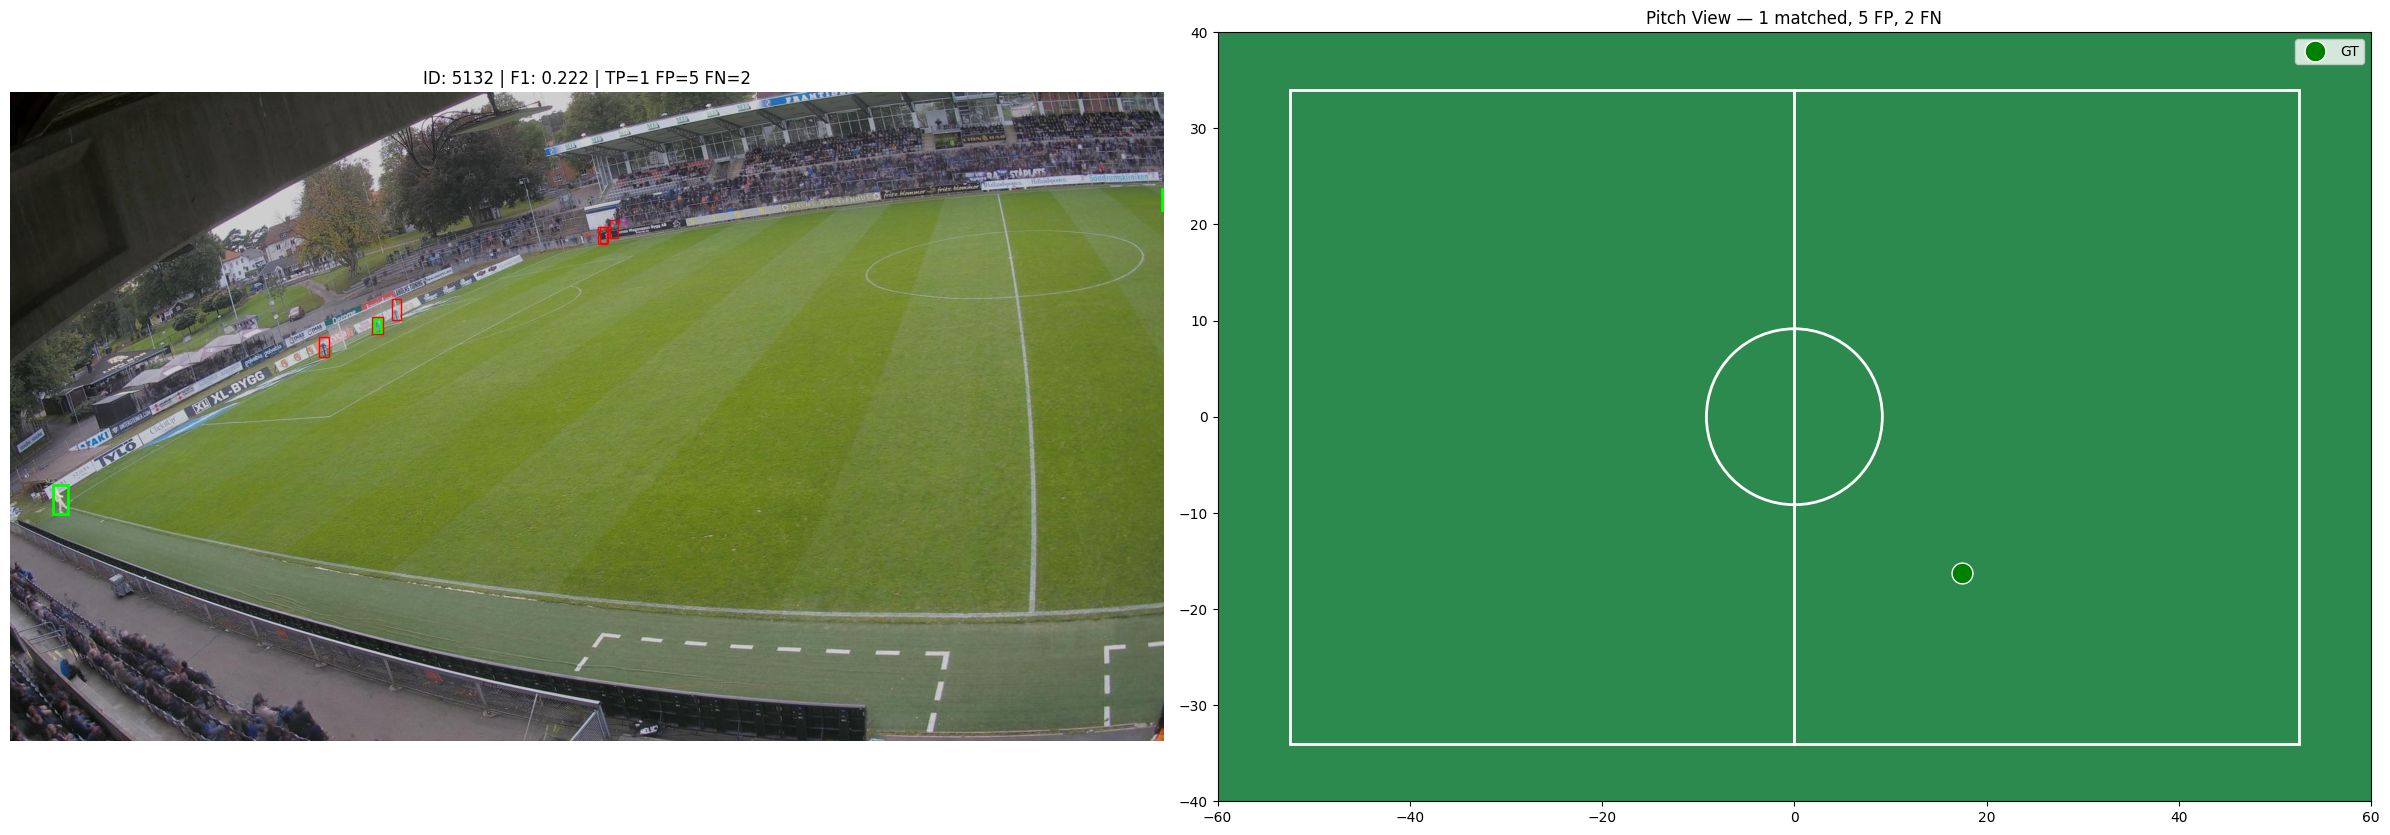


--- Image 5132 | F1=0.222 | TP=1 FP=5 FN=2 ---


Primary error (missed_small/missed_occluded/missed_edge/false_positive_ref/false_positive_crowd/bad_keypoint/wrong_localization/other):  false_positive_ref/false_positive_crowd
Notes:  FP zaznaczyl sedziego i kibicow(bande), FN zawodnik przy krawedzi obrazu


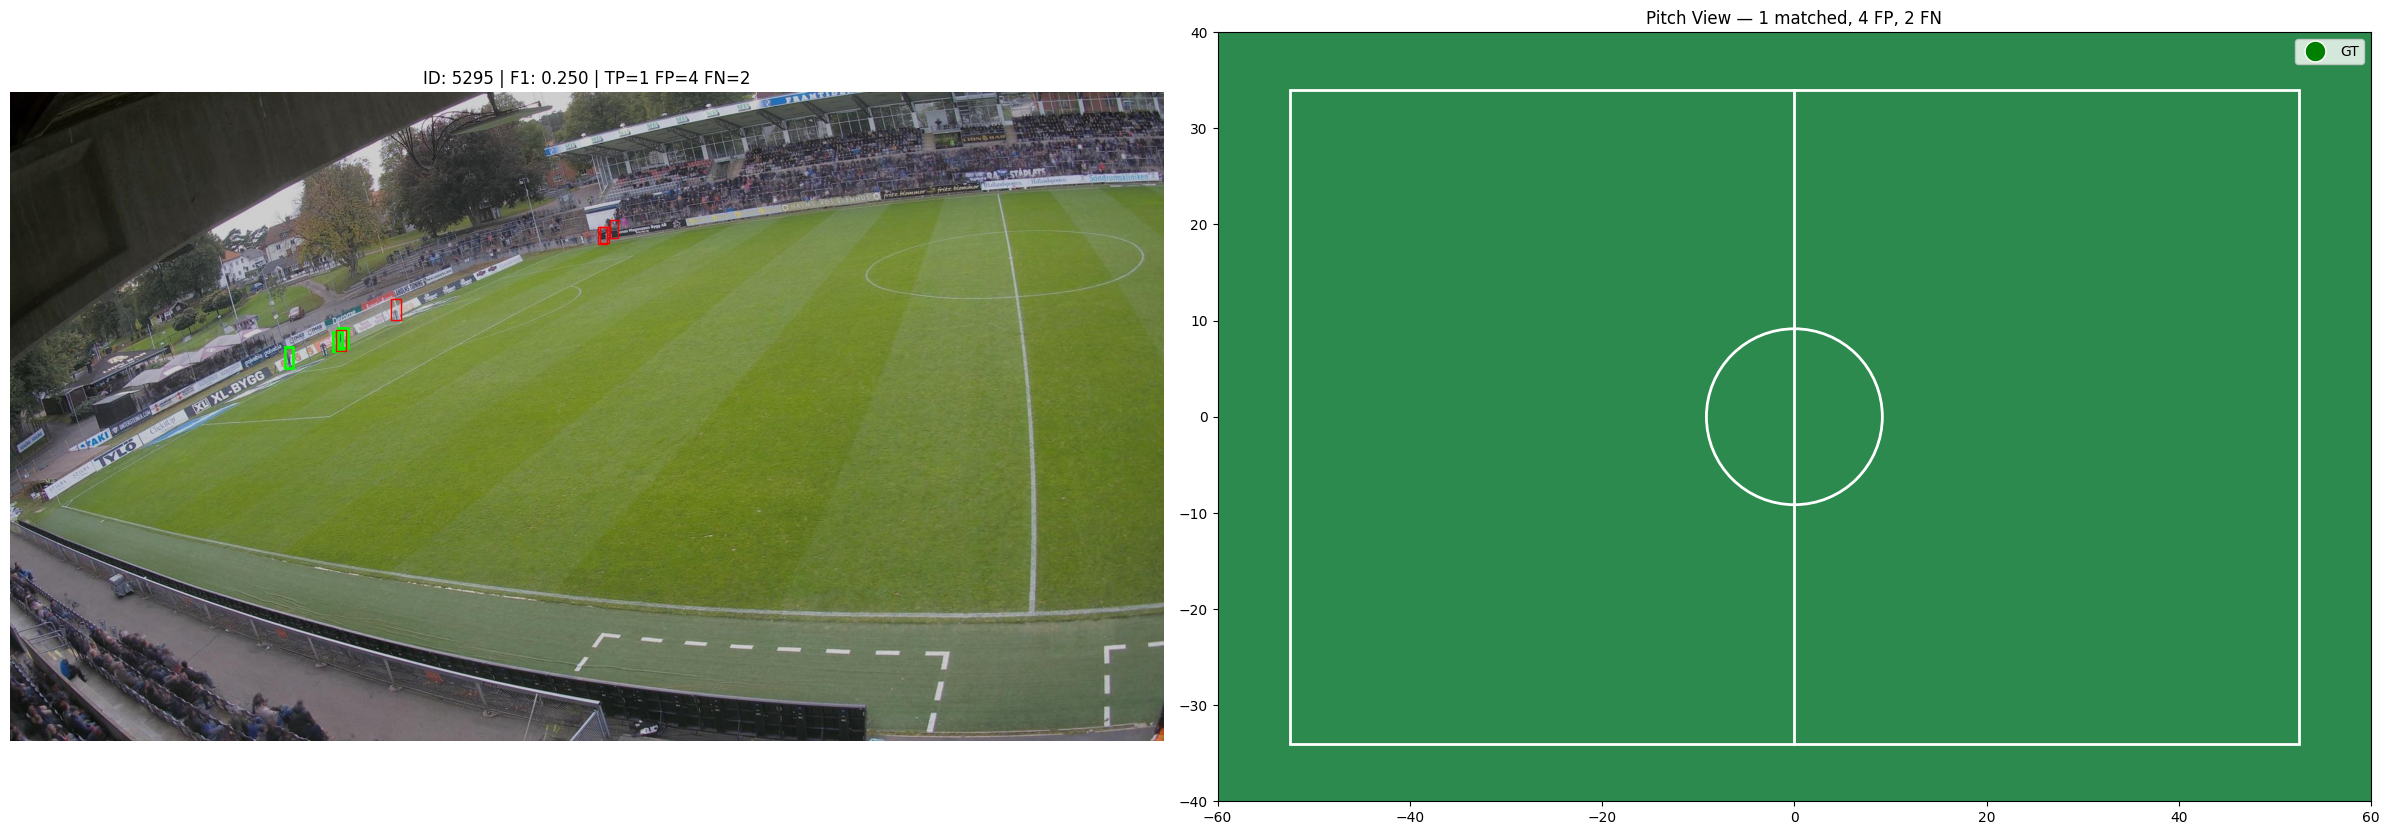


--- Image 5295 | F1=0.250 | TP=1 FP=4 FN=2 ---


Primary error (missed_small/missed_occluded/missed_edge/false_positive_ref/false_positive_crowd/bad_keypoint/wrong_localization/other):  false_positive_ref/false_positive_crowd
Notes:  4 FP (trybuny i pacholek), 2FN i jeden TP


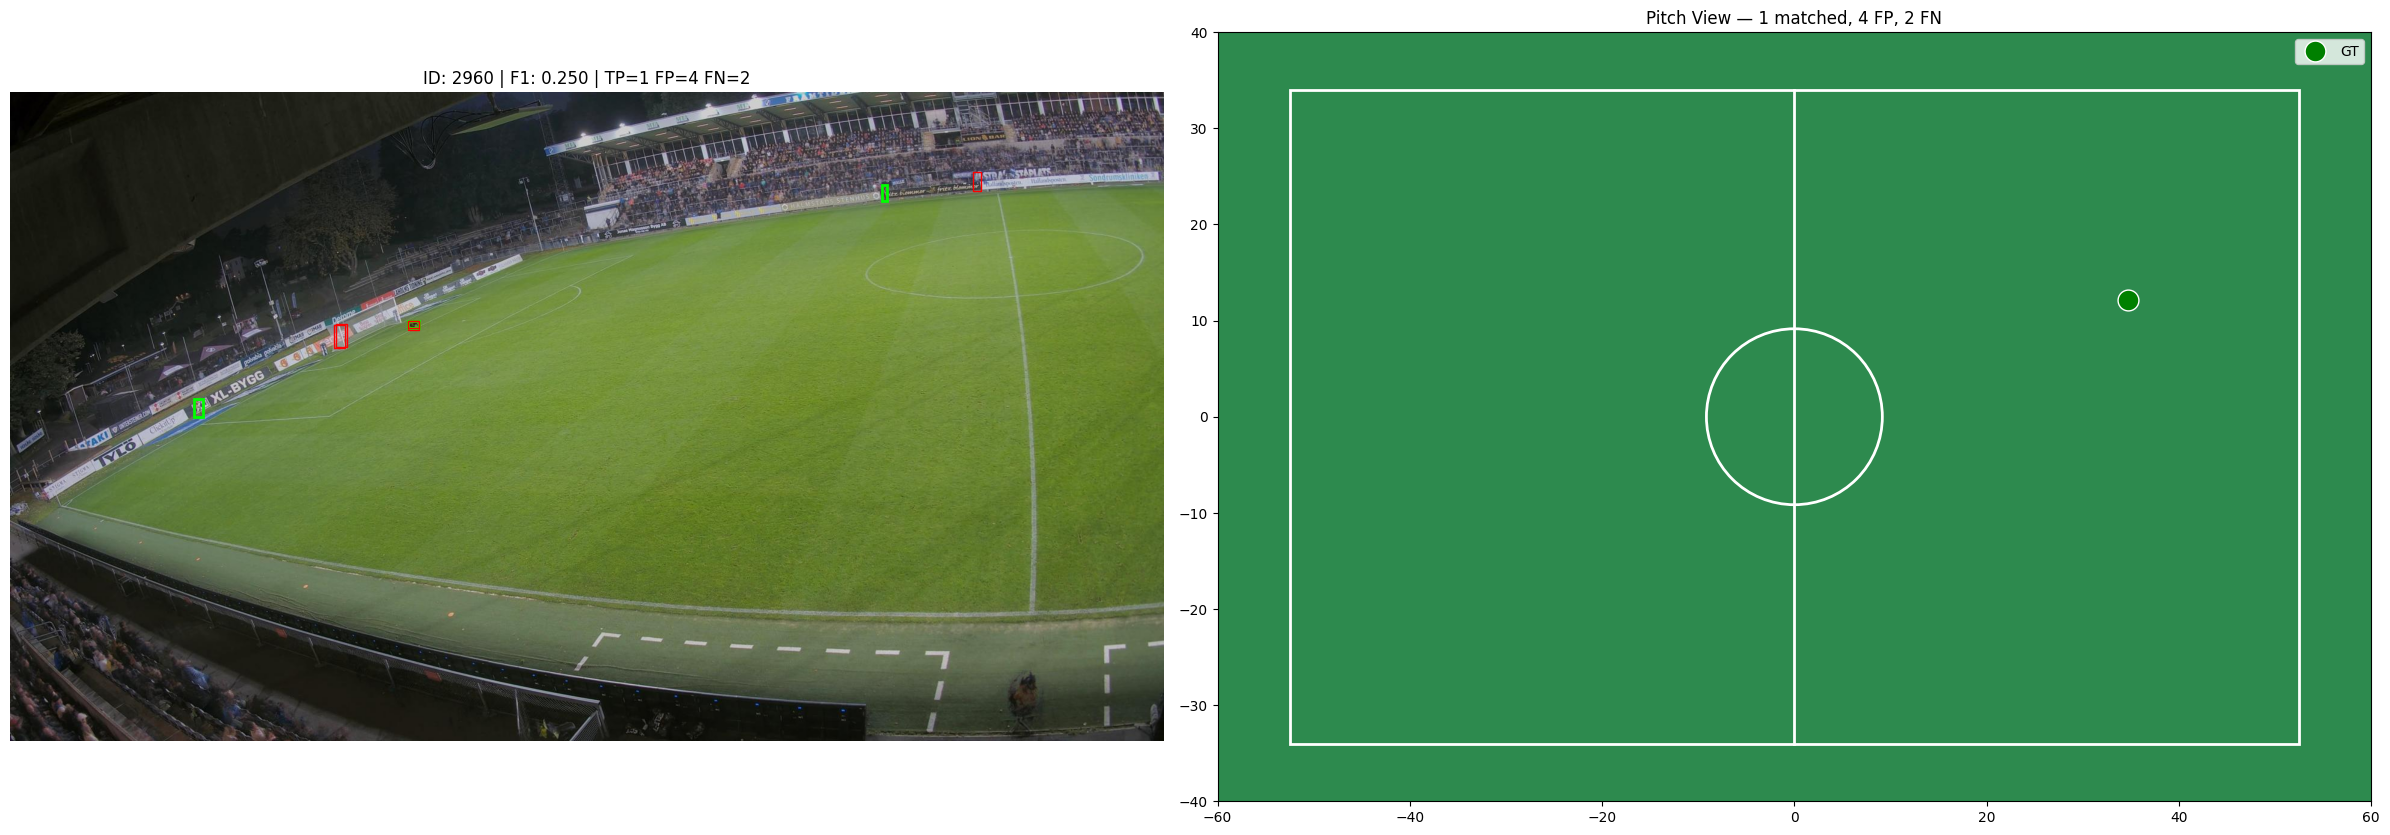


--- Image 2960 | F1=0.250 | TP=1 FP=4 FN=2 ---


Primary error (missed_small/missed_occluded/missed_edge/false_positive_ref/false_positive_crowd/bad_keypoint/wrong_localization/other):  s
Notes:  s


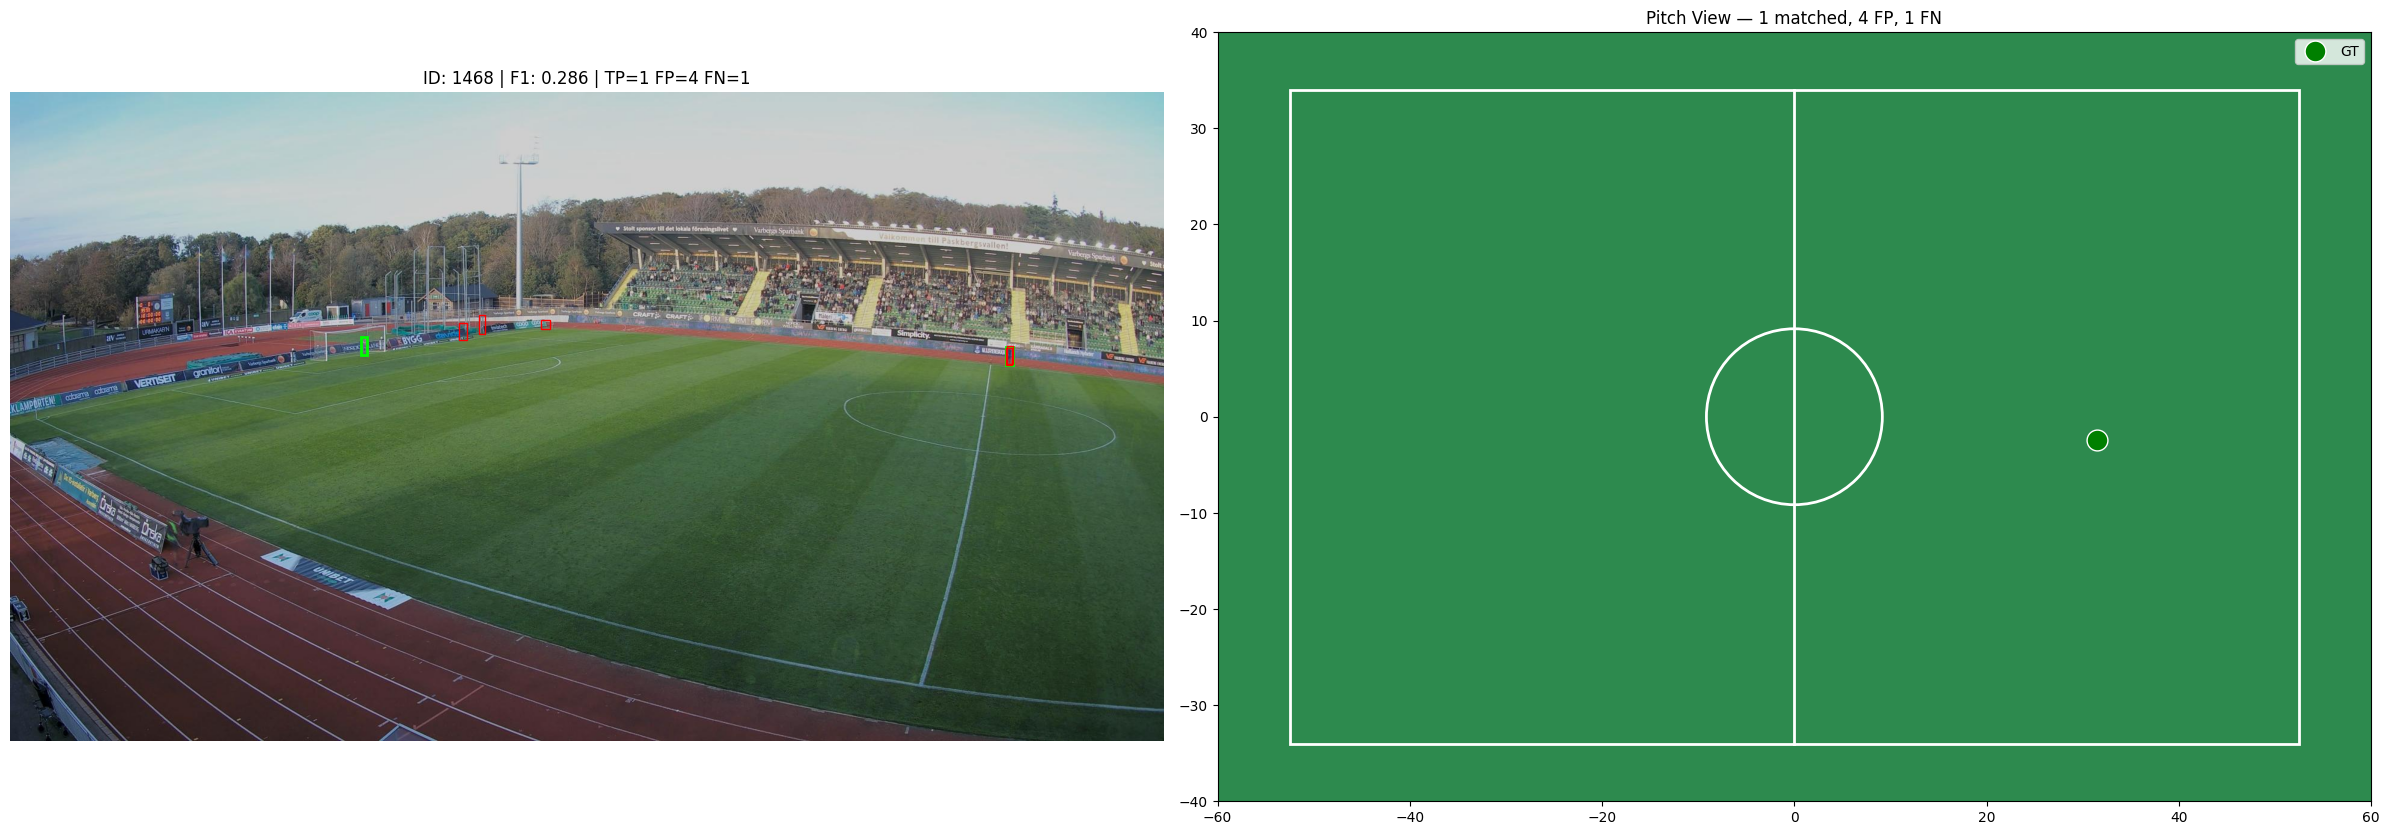


--- Image 1468 | F1=0.286 | TP=1 FP=4 FN=1 ---


In [ ]:
results = []
top50 = scores.head(50)

for idx, row in top50.iterrows():
    img_id = int(row['image_id'])
    file_name = img_info[img_id]['file_name']
    
    # Załaduj obraz
    img_path = Path('top50_worst_images') / file_name.split('/')[-1]
    if not img_path.exists():
        continue
    
    img = Image.open(img_path)
    preds = predictions.get(img_id, [])
    gts = gt_per_image.get(img_id, [])
    matches, unmatched_p, unmatched_g = match_pred_to_gt(preds, gts)
    
    # Oblicz błędy na pitchu dla matched detekcji
    pitch_errors = []
    for p_idx, gt_idx, _ in matches:
        p = preds[p_idx]
        g = gts[gt_idx]
        pred_pos = p.get('position_on_pitch')
        gt_pos = g.get('position_on_pitch')
        if pred_pos and gt_pos:
            err = np.linalg.norm(np.array(pred_pos) - np.array(gt_pos))
            pitch_errors.append(err)
    
    # Wyświetl obraz i pitch obok siebie
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    
    # === LEWY: Obraz z bounding boxami ===
    axes[0].imshow(img)
    
    # GT - zielone
    for g in gts:
        bbox = g['bbox']
        scale = img.width / 3840.0
        x, y, w, h = [v * scale for v in bbox]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, 
                                  edgecolor='lime', facecolor='none')
        axes[0].add_patch(rect)
    
    # Predykcje - czerwone
    for p in preds:
        if p.get('bbox_fullhd') is not None:
            x1, y1, x2, y2 = p['bbox_fullhd']
            scale = img.width / 1920.0
            rect = patches.Rectangle((x1*scale, y1*scale), 
                                      (x2-x1)*scale, (y2-y1)*scale,
                                      linewidth=1, edgecolor='red', facecolor='none')
            axes[0].add_patch(rect)
    
    axes[0].set_title(f'ID: {img_id} | F1: {row["f1"]:.3f} | '
                      f'TP={row["tp"]} FP={row["fp"]} FN={row["fn"]}')
    axes[0].axis('off')
    
    # === PRAWY: Pitch view (top-down) ===
    axes[1].set_facecolor('#2d8a4e')  # zielone boisko
    
    # Rysuj boisko
    pitch_rect = plt.Rectangle((-52.5, -34), 105, 68, fill=False, 
                               edgecolor='white', linewidth=2)
    axes[1].add_patch(pitch_rect)
    
    # Linia środkowa
    axes[1].plot([0, 0], [-34, 34], 'white', linewidth=2)
    # Koło środkowe
    center_circle = plt.Circle((0, 0), 9.15, fill=False, edgecolor='white', linewidth=2)
    axes[1].add_patch(center_circle)
    
    # GT positions - zielone kropki (WIĘKSZE)
    for i, g in enumerate(gts):
        if 'position_on_pitch' in g:
            pos = g['position_on_pitch']
            if i == 0:  # tylko pierwszy z labelką w legendzie
                axes[1].plot(pos[0], pos[1], 'go', markersize=15, 
                           markeredgecolor='white', markeredgewidth=1, label='GT')
            else:
                axes[1].plot(pos[0], pos[1], 'go', markersize=15, 
                           markeredgecolor='white', markeredgewidth=1)
    
    # Predicted positions - czerwone kropki (MNIEJSZE)
    for i, p in enumerate(preds):
        if p.get('position_on_pitch') is not None:
            pos = p['position_on_pitch']
            if i == 0:  # tylko pierwszy z labelką
                axes[1].plot(pos[0], pos[1], 'ro', markersize=10, 
                           markeredgecolor='white', markeredgewidth=1, label='Pred')
            else:
                axes[1].plot(pos[0], pos[1], 'ro', markersize=10, 
                           markeredgecolor='white', markeredgewidth=1)
    
    # Statystyki pitch
    pitch_stats = ""
    if pitch_errors:
        pitch_stats = f' | Pitch err: mean={np.mean(pitch_errors):.1f}m, max={np.max(pitch_errors):.1f}m'
    
    axes[1].set_xlim(-60, 60)
    axes[1].set_ylim(-40, 40)
    axes[1].set_aspect('equal')
    axes[1].legend(loc='upper right')
    axes[1].set_title(f'Pitch View — {len(matches)} matched, '
                      f'{len(unmatched_p)} FP, {len(unmatched_g)} FN{pitch_stats}')
    
    plt.tight_layout()
    plt.show()
    
    # Zapytaj o kategorię
    print(f"\n--- Image {img_id} | F1={row['f1']:.3f} | TP={row['tp']} FP={row['fp']} FN={row['fn']} ---")
    if pitch_errors:
        print(f"Pitch errors: mean={np.mean(pitch_errors):.1f}m, max={np.max(pitch_errors):.1f}m")
        if np.mean(pitch_errors) > 3:
            print("⚠️  DUŻY błąd na pitchu - rozważ bad_keypoint lub wrong_localization!")
    
    error_type = input("Primary error (missed_small/missed_occluded/missed_edge/"
                       "false_positive_ref/false_positive_crowd/bad_keypoint/wrong_localization/other): ")
    notes = input("Notes: ")
    
    results.append({
        'image_id': img_id,
        'file_name': file_name,
        'f1': row['f1'],
        'tp': row['tp'], 'fp': row['fp'], 'fn': row['fn'],
        'pitch_error_mean': np.mean(pitch_errors) if pitch_errors else 0,
        'pitch_error_max': np.max(pitch_errors) if pitch_errors else 0,
        'primary_error': error_type,
        'notes': notes
    })
    
    plt.close('all')
    print("\n" + "="*80 + "\n")

# Zapisz wyniki
results_df = pd.DataFrame(results)
print("\n=== FINAL SUMMARY ===")
print(results_df['primary_error'].value_counts())
results_df.to_csv('failure_analysis_results_with_pitch.csv', index=False)
print("\nResults saved to failure_analysis_results_with_pitch.csv")

In [ ]:
results_df = pd.DataFrame(results)
print(results_df['primary_error'].value_counts())
results_df.to_csv('failure_analysis_results.csv', index=False)